Работа с табличными данными

In [388]:
import pandas as pd

In [389]:
df = pd.read_csv('dataset/train.csv', sep="|")
df

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


In [390]:
df.dtypes

trustLevel                     int64
totalScanTimeInSeconds         int64
grandTotal                   float64
lineItemVoids                  int64
scansWithoutRegistration       int64
quantityModifications          int64
scannedLineItemsPerSecond    float64
valuePerSecond               float64
lineItemVoidsPerPosition     float64
fraud                          int64
dtype: object

In [391]:
df.isna().sum()

trustLevel                   0
totalScanTimeInSeconds       0
grandTotal                   0
lineItemVoids                0
scansWithoutRegistration     0
quantityModifications        0
scannedLineItemsPerSecond    0
valuePerSecond               0
lineItemVoidsPerPosition     0
fraud                        0
dtype: int64

In [392]:
df.fraud.value_counts()

fraud
0    1775
1     104
Name: count, dtype: int64

In [393]:
y = df["fraud"]
X = df.drop(columns=["fraud"])

In [394]:
df.describe()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
count,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000
mean,3.401809,932.153273,50.864492,5.469931,4.904204,2.525279,0.058138,0.201746,0.745404,0.055349
std,1.709404,530.144640,28.940202,3.451169,3.139697,1.695472,0.278512,1.242135,1.327241,0.228720
min,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000548,0.000007,0.000000,0.000000
25%,2.000000,474.500000,25.965000,2.000000,2.000000,1.000000,0.008384,0.027787,0.160000,0.000000
50%,3.000000,932.000000,51.210000,5.000000,5.000000,3.000000,0.016317,0.054498,0.350000,0.000000
75%,5.000000,1397.000000,77.285000,8.000000,8.000000,4.000000,0.032594,0.107313,0.666667,0.000000
max,6.000000,1831.000000,99.960000,11.000000,10.000000,5.000000,6.666667,37.870000,11.000000,1.000000


## Предобработка данных

In [395]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [396]:
X_train.shape

(1503, 9)

In [397]:
X_val.shape

(376, 9)

In [398]:
X_test = pd.read_csv("dataset/test.csv", sep="|")
X_test

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition
0,4,467,88.48,4,8,4,0.014989,0.189465,0.571429
1,3,1004,58.99,7,6,1,0.026892,0.058755,0.259259
2,1,162,14.00,4,5,4,0.006173,0.086420,4.000000
3,5,532,84.79,9,3,4,0.026316,0.159380,0.642857
4,5,890,42.16,4,0,0,0.021348,0.047371,0.210526
...,...,...,...,...,...,...,...,...,...
498116,4,783,59.10,2,2,0,0.012771,0.075479,0.200000
498117,1,278,98.90,9,5,4,0.050360,0.355755,0.642857
498118,3,300,5.41,6,6,4,0.030000,0.018033,0.666667
498119,2,1524,33.97,2,5,3,0.005906,0.022290,0.222222


In [399]:
y_test = pd.read_csv("dataset/DMC-2019-realclass.csv", sep="|")["fraud"]
y_test.value_counts()

fraud
0    474394
1     23727
Name: count, dtype: int64

In [400]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [401]:
import torch

In [402]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [403]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [404]:
from torch.utils.data import TensorDataset, DataLoader

In [405]:
BATCH_SIZE = 64

In [406]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1024)

вес для редкого класса, чтобы модель его не пропускала

In [407]:
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

In [408]:
pos_weight = n_neg / n_pos
pos_weight

tensor(17.1084)

## Подготовка

In [409]:
from dotenv import load_dotenv
import wandb
import os
import logging
import time

timestamp = str(time.time()).replace('.', '_')
log_file = f'part_2_{timestamp}.log'
logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "gp5")
WANDB_ENTITY = os.getenv("WANDB_ENTITY")

logging.info("Ключи для WANDB подгружены")


In [410]:
wandb.login(key=WANDB_API_KEY)
logging.info("Залогинились в wandb")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/maxsafonov/.netrc


In [411]:
import torch.nn as nn

In [463]:
config = {
    "model": "MLP",
    "optimizer": str(optimizer.__class__.__name__),
    "task": "fraud_detection",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "pos_weight": pos_weight,
    "loss": str(loss_fn.__class__.__name__),
    "architecture": str(model)
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="nn_baseline", config=config)

In [525]:
import random
def evaluate_model(model, X, y, threshold=0.5, name="dataset"):
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED) 

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)

    y_true = y.numpy().ravel()
    y_prob = probs.numpy().ravel()
    y_pred = (y_prob > threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    avg_precision = average_precision_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f05 = fbeta_score(y_true, y_pred, beta=0.5)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    profit = tp * 5 - fp * 25 - fn * 5

    print(name)
    print("ROC-AUC:", round(roc_auc, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F0.5-score:", round(f05, 4))
    print("Profit:", profit)
    print()

    return {
        "dataset": name,
        "threshold": threshold,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "precision": precision,
        "recall": recall,
        "f05": f05,
        "profit": profit,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [526]:
import copy
import random

def train_model(
    model,
    train_loader,
    X_valid,
    y_valid,
    loss_fn,
    optimizer,
    epochs=30,
    threshold=0.5,
    model_name="model"
):

    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED) 
    best_metric = -10**9
    best_epoch = 0
    best_state = None

    history = []

    logging.info(f"Начали обучение {model_name}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        valid_metrics = evaluate_model(
            model,
            X_valid,
            y_valid,
            threshold=threshold,
            name=f"{model_name} | valid epoch {epoch}"
        )

        current_metric = valid_metrics["roc_auc"]

        if current_metric > best_metric:
            best_metric = current_metric
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        history.append({
            "epoch": epoch,
            "train_loss": epoch_loss,
            **valid_metrics
        })

        print(
            f"Эпоха {epoch:02d} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Val ROC-AUC: {valid_metrics['roc_auc']:.4f} | "
            f"Val Profit: {valid_metrics['profit']}"
        )

        # wandb.log({
        #     f"{model_name}/epoch": epoch,
        #     f"{model_name}/train_loss": epoch_loss,
        #     f"{model_name}/valid_profit": valid_metrics["profit"],
        #     f"{model_name}/valid_roc_auc": valid_metrics["roc_auc"],
        #     f"{model_name}/valid_average_precision": valid_metrics["average_precision"],
        #     f"{model_name}/valid_precision": valid_metrics["precision"],
        #     f"{model_name}/valid_recall": valid_metrics["recall"],
        #     f"{model_name}/valid_f05": valid_metrics["f05"],
        # })

    model.load_state_dict(best_state)

    print()
    print(f"Лучшая эпоха для {model_name}: {best_epoch}")
    print(f"Лучший ROC-AUC: {best_metric}")

    return model, history

## model_1_baseline

In [535]:
EPOCHS = 30
LR = 0.01
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 

model_1 = nn.Sequential(
    nn.Linear(9, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_1.parameters(), lr=LR)

model_1, history_1 = train_model(
    model=model_1,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_1_baseline"
)

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


model_1_baseline | valid epoch 1
ROC-AUC: 0.9315
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 01 | Train Loss: 1.3152 | Val ROC-AUC: 0.9315 | Val Profit: -105
model_1_baseline | valid epoch 2
ROC-AUC: 0.9522
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 02 | Train Loss: 1.1563 | Val ROC-AUC: 0.9522 | Val Profit: -105
model_1_baseline | valid epoch 3
ROC-AUC: 0.9532
Precision: 0.2917
Recall: 1.0
F0.5-score: 0.3398
Profit: -1170

Эпоха 03 | Train Loss: 0.7766 | Val ROC-AUC: 0.9532 | Val Profit: -1170
model_1_baseline | valid epoch 4
ROC-AUC: 0.9596
Precision: 0.3134
Recall: 1.0
F0.5-score: 0.3633
Profit: -1045

Эпоха 04 | Train Loss: 0.4706 | Val ROC-AUC: 0.9596 | Val Profit: -1045
model_1_baseline | valid epoch 5
ROC-AUC: 0.9628
Precision: 0.3134
Recall: 1.0
F0.5-score: 0.3633
Profit: -1045

Эпоха 05 | Train Loss: 0.4148 | Val ROC-AUC: 0.9628 | Val Profit: -1045
model_1_baseline | valid epoch 6
ROC-AUC: 0.965
Precision: 0.3134
Recall: 1.0
F0.5-score: 0

In [536]:
train_metrics = evaluate_model(model_1, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_1, X_test, y_test, threshold=0.5, name="Test")

# еще можно написать функцию для поиска лучшего порога, но это если время останется

Train
ROC-AUC: 0.9913
Precision: 0.453
Recall: 0.988
F0.5-score: 0.5081
Profit: -2070

Test
ROC-AUC: 0.9822
Precision: 0.392
Recall: 0.9665
F0.5-score: 0.4448
Profit: -778665



Видно сильное переобучение! Я хз, что с этим делать

### Попробуем подобрать порог

In [421]:
with torch.no_grad():
    val_prob = torch.sigmoid(model(X_val)).numpy()

val_true = y_val.numpy()

In [422]:
from sklearn.metrics import precision_recall_curve

target_recall = 0.90

prec, rec, thr = precision_recall_curve(val_true, val_prob)
best_threshold = thr[rec[:-1] >= target_recall].max()
logging.info(f"Подобрали порог {best_threshold}")
wandb.log({"best_threshold": best_threshold})
best_threshold

np.float32(0.81305104)

In [423]:
y_pred = (y_prob > best_threshold).astype(int)

In [424]:
pre_at_score = precision_score(y_true, y_pred)
logging.info(f"На тесте Precision: {pre_at_score}")
pre_at_score

0.35816208911323977

In [425]:
rec_at_score = recall_score(y_true, y_pred)
logging.info(f"На тесте Recall: {rec_at_score}")
rec_at_score

0.759556623256206

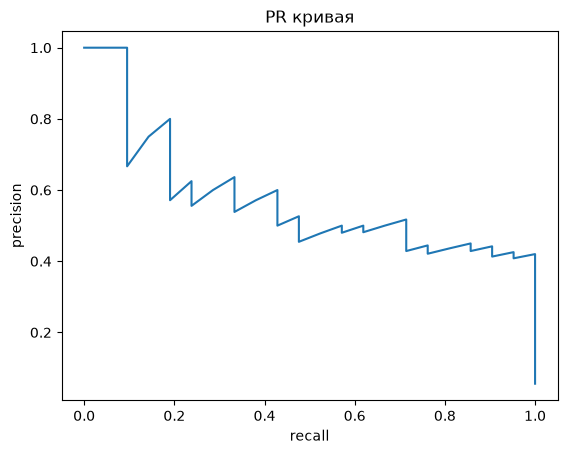

In [426]:
import matplotlib.pyplot as plt

plt.plot(rec, prec)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR кривая")
plt.show()

In [427]:
import pickle

pickle.dump(model.state_dict(), open("models/model_fraud_1.pkl", 'wb'))
logging.info("Сохранили веса модели в папку models")

In [428]:
results = wandb.Table(columns=['model', 'test/roc_auc', 'test/precision', 'test/recall', 'test/recall_new_threshold', 'test/precision_new_threshold'])
results.add_data("nn_baseline", auc_score, pre_score, rec_score, rec_at_score, pre_at_score)
wandb.log({"results": results})

In [429]:
artifact = wandb.Artifact(name="model_fraud_1", type="model", description="Тест логгирования модели MLP")

artifact.add_file("models/model_fraud_1.pkl")
artifact.add_file(log_file)
run.log_artifact(artifact)




<Artifact model_fraud_1>

In [430]:
run.finish()

best_threshold,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,████▇▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_threshold,0.81305
epoch,30
train/loss,0.38736


## model_2_dop_sloi

In [538]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_2 = nn.Sequential(
    nn.Linear(9, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_2.parameters(), lr=LR)

model_2, history_2 = train_model(
    model=model_2,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_2_dop_sloi"
)

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


model_2_dop_sloi | valid epoch 1
ROC-AUC: 0.9447
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 01 | Train Loss: 1.2926 | Val ROC-AUC: 0.9447 | Val Profit: -105
model_2_dop_sloi | valid epoch 2
ROC-AUC: 0.9504
Precision: 0.3333
Recall: 0.8571
F0.5-score: 0.3797
Profit: -825

Эпоха 02 | Train Loss: 0.9026 | Val ROC-AUC: 0.9504 | Val Profit: -825
model_2_dop_sloi | valid epoch 3
ROC-AUC: 0.9525
Precision: 0.28
Recall: 1.0
F0.5-score: 0.3271
Profit: -1245

Эпоха 03 | Train Loss: 0.5462 | Val ROC-AUC: 0.9525 | Val Profit: -1245
model_2_dop_sloi | valid epoch 4
ROC-AUC: 0.9621
Precision: 0.3182
Recall: 1.0
F0.5-score: 0.3684
Profit: -1020

Эпоха 04 | Train Loss: 0.4318 | Val ROC-AUC: 0.9621 | Val Profit: -1020
model_2_dop_sloi | valid epoch 5
ROC-AUC: 0.9678
Precision: 0.3281
Recall: 1.0
F0.5-score: 0.3791
Profit: -970

Эпоха 05 | Train Loss: 0.3975 | Val ROC-AUC: 0.9678 | Val Profit: -970
model_2_dop_sloi | valid epoch 6
ROC-AUC: 0.971
Precision: 0.3281
Recall: 1.0
F0.5-sco

In [539]:
train_metrics = evaluate_model(model_2, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_2, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9941
Precision: 0.497
Recall: 1.0
F0.5-score: 0.5526
Profit: -1685

Test
ROC-AUC: 0.9837
Precision: 0.4179
Recall: 0.9525
F0.5-score: 0.4707
Profit: -679700



## model_3_bolshe_neyronov

In [531]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 

model_3 = nn.Sequential(
    nn.Linear(9, 32),
    nn.ReLU(),
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_3.parameters(), lr=LR)

model_3, history_3 = train_model(
    model=model_3,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_3_bolshe_neyronov"
)

model_3_bolshe_neyronov | valid epoch 1
ROC-AUC: 0.9496
Precision: 0.2532
Recall: 0.9524
F0.5-score: 0.2967
Profit: -1380

Эпоха 01 | Train Loss: 1.1532 | Val ROC-AUC: 0.9496 | Val Profit: -1380
model_3_bolshe_neyronov | valid epoch 2
ROC-AUC: 0.9603
Precision: 0.3654
Recall: 0.9048
F0.5-score: 0.4148
Profit: -740

Эпоха 02 | Train Loss: 0.5199 | Val ROC-AUC: 0.9603 | Val Profit: -740
model_3_bolshe_neyronov | valid epoch 3
ROC-AUC: 0.9641
Precision: 0.375
Recall: 1.0
F0.5-score: 0.4286
Profit: -770

Эпоха 03 | Train Loss: 0.4594 | Val ROC-AUC: 0.9641 | Val Profit: -770
model_3_bolshe_neyronov | valid epoch 4
ROC-AUC: 0.9671
Precision: 0.2917
Recall: 1.0
F0.5-score: 0.3398
Profit: -1170

Эпоха 04 | Train Loss: 0.4168 | Val ROC-AUC: 0.9671 | Val Profit: -1170
model_3_bolshe_neyronov | valid epoch 5
ROC-AUC: 0.9696
Precision: 0.375
Recall: 1.0
F0.5-score: 0.4286
Profit: -770

Эпоха 05 | Train Loss: 0.3698 | Val ROC-AUC: 0.9696 | Val Profit: -770
model_3_bolshe_neyronov | valid epoch 6
RO

In [532]:
train_metrics = evaluate_model(model_3, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_3, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9947
Precision: 0.6308
Recall: 0.988
F0.5-score: 0.6799
Profit: -795

Test
ROC-AUC: 0.984
Precision: 0.5123
Recall: 0.886
F0.5-score: 0.5595
Profit: -408765



## model_4_tolko_batchnorm

In [540]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_4 = nn.Sequential(
    nn.Linear(9, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_4.parameters(), lr=LR)

model_4, history_4 = train_model(
    model=model_4,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_4_tolko_batchnorm"
)

model_4_tolko_batchnorm | valid epoch 1
ROC-AUC: 0.9347
Precision: 0.1835
Recall: 0.9524
F0.5-score: 0.2188
Profit: -2130

Эпоха 01 | Train Loss: 1.0766 | Val ROC-AUC: 0.9347 | Val Profit: -2130
model_4_tolko_batchnorm | valid epoch 2
ROC-AUC: 0.9502
Precision: 0.2597
Recall: 0.9524
F0.5-score: 0.304
Profit: -1330

Эпоха 02 | Train Loss: 0.6381 | Val ROC-AUC: 0.9502 | Val Profit: -1330
model_4_tolko_batchnorm | valid epoch 3
ROC-AUC: 0.9555
Precision: 0.3182
Recall: 1.0
F0.5-score: 0.3684
Profit: -1020

Эпоха 03 | Train Loss: 0.4899 | Val ROC-AUC: 0.9555 | Val Profit: -1020
model_4_tolko_batchnorm | valid epoch 4
ROC-AUC: 0.9449
Precision: 0.2763
Recall: 1.0
F0.5-score: 0.3231
Profit: -1270

Эпоха 04 | Train Loss: 0.4353 | Val ROC-AUC: 0.9449 | Val Profit: -1270
model_4_tolko_batchnorm | valid epoch 5
ROC-AUC: 0.9677
Precision: 0.2658
Recall: 1.0
F0.5-score: 0.3116
Profit: -1345

Эпоха 05 | Train Loss: 0.4288 | Val ROC-AUC: 0.9677 | Val Profit: -1345
model_4_tolko_batchnorm | valid epo

In [541]:
train_metrics = evaluate_model(model_4, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_4, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9906
Precision: 0.5
Recall: 0.988
F0.5-score: 0.5548
Profit: -1645

Test
ROC-AUC: 0.9673
Precision: 0.3997
Recall: 0.8956
F0.5-score: 0.4495
Profit: -704025



Батч норм вообще не помог, а только ухудшил качество

## model_5_tolko_dropout

In [573]:
EPOCHS = 40
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_5 = nn.Sequential(
    nn.Linear(9, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_5.parameters(), lr=LR)

model_5, history_5 = train_model(
    model=model_5,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_5_tolko_dropout"
)

model_5_tolko_dropout | valid epoch 1
ROC-AUC: 0.9536
Precision: 0.6667
Recall: 0.0952
F0.5-score: 0.303
Profit: -110

Эпоха 01 | Train Loss: 1.3226 | Val ROC-AUC: 0.9536 | Val Profit: -110
model_5_tolko_dropout | valid epoch 2
ROC-AUC: 0.9482
Precision: 0.3088
Recall: 1.0
F0.5-score: 0.3584
Profit: -1070

Эпоха 02 | Train Loss: 1.0351 | Val ROC-AUC: 0.9482 | Val Profit: -1070
model_5_tolko_dropout | valid epoch 3
ROC-AUC: 0.9462
Precision: 0.1448
Recall: 1.0
F0.5-score: 0.1747
Profit: -2995

Эпоха 03 | Train Loss: 0.7650 | Val ROC-AUC: 0.9462 | Val Profit: -2995
model_5_tolko_dropout | valid epoch 4
ROC-AUC: 0.9501
Precision: 0.2838
Recall: 1.0
F0.5-score: 0.3312
Profit: -1220

Эпоха 04 | Train Loss: 0.6429 | Val ROC-AUC: 0.9501 | Val Profit: -1220
model_5_tolko_dropout | valid epoch 5
ROC-AUC: 0.9547
Precision: 0.3281
Recall: 1.0
F0.5-score: 0.3791
Profit: -970

Эпоха 05 | Train Loss: 0.5119 | Val ROC-AUC: 0.9547 | Val Profit: -970
model_5_tolko_dropout | valid epoch 6
ROC-AUC: 0.953

In [551]:
train_metrics = evaluate_model(model_5, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_5, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9726
Precision: 0.5701
Recall: 0.7349
F0.5-score: 0.5969
Profit: -955

Test
ROC-AUC: 0.9617
Precision: 0.4403
Recall: 0.6262
F0.5-score: 0.4681
Profit: -442290



## model_6_batchnorm_i_dropout

In [553]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_6 = nn.Sequential(
    nn.Linear(9, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_6.parameters(), lr=LR)

model_6, history_6 = train_model(
    model=model_6,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_6_batchnorm_i_dropout"
)

model_6_batchnorm_i_dropout | valid epoch 1
ROC-AUC: 0.929
Precision: 0.1167
Recall: 1.0
F0.5-score: 0.1417
Profit: -3870

Эпоха 01 | Train Loss: 1.2472 | Val ROC-AUC: 0.9290 | Val Profit: -3870
model_6_batchnorm_i_dropout | valid epoch 2
ROC-AUC: 0.9382
Precision: 0.1479
Recall: 1.0
F0.5-score: 0.1783
Profit: -2920

Эпоха 02 | Train Loss: 0.9384 | Val ROC-AUC: 0.9382 | Val Profit: -2920
model_6_batchnorm_i_dropout | valid epoch 3
ROC-AUC: 0.9406
Precision: 0.2326
Recall: 0.9524
F0.5-score: 0.274
Profit: -1555

Эпоха 03 | Train Loss: 0.6659 | Val ROC-AUC: 0.9406 | Val Profit: -1555
model_6_batchnorm_i_dropout | valid epoch 4
ROC-AUC: 0.9331
Precision: 0.3721
Recall: 0.7619
F0.5-score: 0.4145
Profit: -620

Эпоха 04 | Train Loss: 0.4174 | Val ROC-AUC: 0.9331 | Val Profit: -620
model_6_batchnorm_i_dropout | valid epoch 5
ROC-AUC: 0.926
Precision: 0.3421
Recall: 0.619
F0.5-score: 0.3757
Profit: -600

Эпоха 05 | Train Loss: 0.2998 | Val ROC-AUC: 0.9260 | Val Profit: -600
model_6_batchnorm_i

In [554]:
train_metrics = evaluate_model(model_6, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_6, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9656
Precision: 0.5909
Recall: 0.4699
F0.5-score: 0.562
Profit: -700

Test
ROC-AUC: 0.9484
Precision: 0.4857
Recall: 0.4361
F0.5-score: 0.4749
Profit: -289065



## model_7_leaky_relu

In [561]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_7 = nn.Sequential(
    nn.Linear(9, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(negative_slope=0.02),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.LeakyReLU(negative_slope=0.02),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.LeakyReLU(negative_slope=0.02),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.LeakyReLU(negative_slope=0.02),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.LeakyReLU(negative_slope=0.02),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_7.parameters(), lr=LR)

model_7, history_7 = train_model(
    model=model_7,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_7_leaky_relu"
)

model_7_leaky_relu | valid epoch 1
ROC-AUC: 0.9072
Precision: 0.1266
Recall: 0.9524
F0.5-score: 0.1531
Profit: -3355

Эпоха 01 | Train Loss: 1.2863 | Val ROC-AUC: 0.9072 | Val Profit: -3355
model_7_leaky_relu | valid epoch 2
ROC-AUC: 0.9494
Precision: 0.1556
Recall: 1.0
F0.5-score: 0.1872
Profit: -2745

Эпоха 02 | Train Loss: 1.0173 | Val ROC-AUC: 0.9494 | Val Profit: -2745
model_7_leaky_relu | valid epoch 3
ROC-AUC: 0.9591
Precision: 0.4167
Recall: 0.7143
F0.5-score: 0.4545
Profit: -480

Эпоха 03 | Train Loss: 0.6737 | Val ROC-AUC: 0.9591 | Val Profit: -480
model_7_leaky_relu | valid epoch 4
ROC-AUC: 0.9451
Precision: 0.3556
Recall: 0.7619
F0.5-score: 0.398
Profit: -670

Эпоха 04 | Train Loss: 0.4413 | Val ROC-AUC: 0.9451 | Val Profit: -670
model_7_leaky_relu | valid epoch 5
ROC-AUC: 0.9323
Precision: 0.359
Recall: 0.6667
F0.5-score: 0.3955
Profit: -590

Эпоха 05 | Train Loss: 0.3961 | Val ROC-AUC: 0.9323 | Val Profit: -590
model_7_leaky_relu | valid epoch 6
ROC-AUC: 0.949
Precision: 

In [562]:
train_metrics = evaluate_model(model_7, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_7, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9249
Precision: 0.5333
Recall: 0.1928
F0.5-score: 0.3941
Profit: -605

Test
ROC-AUC: 0.912
Precision: 0.4821
Recall: 0.2241
F0.5-score: 0.3919
Profit: -208305



## model_8_weight_decay

In [568]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_8 = nn.Sequential(
    nn.Linear(9, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_8.parameters(), lr=LR, weight_decay=1e-4)

model_8, history_8 = train_model(
    model=model_8,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_8_weight_decay"
)

model_8_weight_decay | valid epoch 1
ROC-AUC: 0.861
Precision: 0.116
Recall: 1.0
F0.5-score: 0.1409
Profit: -3895

Эпоха 01 | Train Loss: 1.2724 | Val ROC-AUC: 0.8610 | Val Profit: -3895
model_8_weight_decay | valid epoch 2
ROC-AUC: 0.9461
Precision: 0.1409
Recall: 1.0
F0.5-score: 0.1702
Profit: -3095

Эпоха 02 | Train Loss: 0.9681 | Val ROC-AUC: 0.9461 | Val Profit: -3095
model_8_weight_decay | valid epoch 3
ROC-AUC: 0.9421
Precision: 0.2576
Recall: 0.8095
F0.5-score: 0.2982
Profit: -1160

Эпоха 03 | Train Loss: 0.6426 | Val ROC-AUC: 0.9421 | Val Profit: -1160
model_8_weight_decay | valid epoch 4
ROC-AUC: 0.9253
Precision: 0.3902
Recall: 0.7619
F0.5-score: 0.4324
Profit: -570

Эпоха 04 | Train Loss: 0.4125 | Val ROC-AUC: 0.9253 | Val Profit: -570
model_8_weight_decay | valid epoch 5
ROC-AUC: 0.9576
Precision: 0.25
Recall: 1.0
F0.5-score: 0.2941
Profit: -1470

Эпоха 05 | Train Loss: 0.4315 | Val ROC-AUC: 0.9576 | Val Profit: -1470
model_8_weight_decay | valid epoch 6
ROC-AUC: 0.9595
Pr

In [569]:
train_metrics = evaluate_model(model_8, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_8, X_test, y_test, threshold=0.5, name="Test")

Train
ROC-AUC: 0.9414
Precision: 0.7174
Recall: 0.3976
F0.5-score: 0.618
Profit: -410

Test
ROC-AUC: 0.9261
Precision: 0.5832
Recall: 0.3379
F0.5-score: 0.5093
Profit: -181705



При этом пришлось обратно вернуться к обычной RELU

## model_9_Focal_loss

In [570]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = self.alpha * (1 - pt) ** self.gamma

        loss = focal_weight * bce_loss

        return loss.mean()

In [571]:
EPOCHS = 30
LR = 0.01

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) 


model_9 = nn.Sequential(
    nn.Linear(9, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(8, 1)
)

loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.Adam(model_9.parameters(), lr=LR, weight_decay=1e-4)

model_9, history_8 = train_model(
    model=model_9,
    train_loader=train_loader,
    X_valid=X_val,
    y_valid=y_val,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    threshold=0.5,
    model_name="model_9_Focal_loss"
)

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/max

model_9_Focal_loss | valid epoch 1
ROC-AUC: 0.9476
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 01 | Train Loss: 0.0234 | Val ROC-AUC: 0.9476 | Val Profit: -105
model_9_Focal_loss | valid epoch 2
ROC-AUC: 0.9478
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 02 | Train Loss: 0.0138 | Val ROC-AUC: 0.9478 | Val Profit: -105
model_9_Focal_loss | valid epoch 3
ROC-AUC: 0.9037
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 03 | Train Loss: 0.0102 | Val ROC-AUC: 0.9037 | Val Profit: -105
model_9_Focal_loss | valid epoch 4
ROC-AUC: 0.9307
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 04 | Train Loss: 0.0083 | Val ROC-AUC: 0.9307 | Val Profit: -105
model_9_Focal_loss | valid epoch 5
ROC-AUC: 0.9564
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 05 | Train Loss: 0.0070 | Val ROC-AUC: 0.9564 | Val Profit: -105
model_9_Focal_loss | valid epoch 6
ROC-AUC: 0.9141
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -10

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/max

model_9_Focal_loss | valid epoch 8
ROC-AUC: 0.9611
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 08 | Train Loss: 0.0060 | Val ROC-AUC: 0.9611 | Val Profit: -105
model_9_Focal_loss | valid epoch 9
ROC-AUC: 0.9186
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 09 | Train Loss: 0.0066 | Val ROC-AUC: 0.9186 | Val Profit: -105
model_9_Focal_loss | valid epoch 10
ROC-AUC: 0.9413
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 10 | Train Loss: 0.0067 | Val ROC-AUC: 0.9413 | Val Profit: -105
model_9_Focal_loss | valid epoch 11
ROC-AUC: 0.9624
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 11 | Train Loss: 0.0067 | Val ROC-AUC: 0.9624 | Val Profit: -105
model_9_Focal_loss | valid epoch 12
ROC-AUC: 0.961
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 12 | Train Loss: 0.0055 | Val ROC-AUC: 0.9610 | Val Profit: -105
model_9_Focal_loss | valid epoch 13
ROC-AUC: 0.9626
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: 

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


model_9_Focal_loss | valid epoch 14
ROC-AUC: 0.9415
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 14 | Train Loss: 0.0043 | Val ROC-AUC: 0.9415 | Val Profit: -105
model_9_Focal_loss | valid epoch 15
ROC-AUC: 0.9583
Precision: 0.5263
Recall: 0.4762
F0.5-score: 0.5155
Profit: -230

Эпоха 15 | Train Loss: 0.0041 | Val ROC-AUC: 0.9583 | Val Profit: -230
model_9_Focal_loss | valid epoch 16
ROC-AUC: 0.875
Precision: 1.0
Recall: 0.0476
F0.5-score: 0.2
Profit: -95

Эпоха 16 | Train Loss: 0.0037 | Val ROC-AUC: 0.8750 | Val Profit: -95
model_9_Focal_loss | valid epoch 17
ROC-AUC: 0.8005
Precision: 0.3333
Recall: 0.0476
F0.5-score: 0.1515
Profit: -145

Эпоха 17 | Train Loss: 0.0045 | Val ROC-AUC: 0.8005 | Val Profit: -145
model_9_Focal_loss | valid epoch 18
ROC-AUC: 0.8848
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -130

Эпоха 18 | Train Loss: 0.0046 | Val ROC-AUC: 0.8848 | Val Profit: -130
model_9_Focal_loss | valid epoch 19
ROC-AUC: 0.9622
Precision: 1.0
Recall: 0.0952


/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/max

model_9_Focal_loss | valid epoch 26
ROC-AUC: 0.7415
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 26 | Train Loss: 0.0021 | Val ROC-AUC: 0.7415 | Val Profit: -105
model_9_Focal_loss | valid epoch 27
ROC-AUC: 0.7937
Precision: 0.5
Recall: 0.0476
F0.5-score: 0.1724
Profit: -120

Эпоха 27 | Train Loss: 0.0018 | Val ROC-AUC: 0.7937 | Val Profit: -120
model_9_Focal_loss | valid epoch 28
ROC-AUC: 0.6131
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -105

Эпоха 28 | Train Loss: 0.0017 | Val ROC-AUC: 0.6131 | Val Profit: -105
model_9_Focal_loss | valid epoch 29
ROC-AUC: 0.7759
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -130

Эпоха 29 | Train Loss: 0.0016 | Val ROC-AUC: 0.7759 | Val Profit: -130
model_9_Focal_loss | valid epoch 30
ROC-AUC: 0.7135
Precision: 0.5
Recall: 0.0476
F0.5-score: 0.1724
Profit: -120

Эпоха 30 | Train Loss: 0.0016 | Val ROC-AUC: 0.7135 | Val Profit: -120

Лучшая эпоха для model_9_Focal_loss: 13
Лучший ROC-AUC: 0.9625754527162977


In [572]:
train_metrics = evaluate_model(model_9, X_train, y_train, threshold=0.5, name="Train")
test_metrics = evaluate_model(model_9, X_test, y_test, threshold=0.5, name="Test")

/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Train
ROC-AUC: 0.9575
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -415



/Users/maxsafonov/gp-5/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Test
ROC-AUC: 0.9372
Precision: 0.0
Recall: 0.0
F0.5-score: 0.0
Profit: -118635



# ансамбль ПОКА НЕ ТРОГАЛ

In [449]:
import numpy as np

In [450]:
def build_model():
    return nn.Sequential(
        nn.Linear(9, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        )

In [451]:
EPOCHS = 120
LR = 0.001
WEIGHT_DECAY = 1e-4
N_ENSEMBLE = 5

net = build_model()
opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [452]:
loss_fn2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [453]:
config = {
    "model": "Ensemble",
    "optimizer": str(opt.__class__.__name__),
    "task": "fraud_detection",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "pos_weight": pos_weight,
    "loss": str(loss_fn2.__class__.__name__),
    "n_ensemble": N_ENSEMBLE,
    "architecture": str(net)
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="ensemble", config=config)

In [454]:
test_probs = []
logging.info("Запустили обучение моделей ансамбля")

np.random.seed(42)
seeds = np.random.randint(1, 525252, size=N_ENSEMBLE)
ensemble = []
for i in range(N_ENSEMBLE):
    seed = seeds[i]
    torch.manual_seed(seed)
    net = build_model()
    opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    logging.info(f"Запустили обучение модели {i+1}. Сид: {seed}")


    net.train()
    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn2(net(xb), yb)
            loss.backward()
            epoch_loss += loss.item()
            opt.step()
        
        logging.info(f"эпоха: {epoch}, loss:  {round(epoch_loss, 4)}")
        wandb.log({"epoch": epoch, f"ensemble/{i}/train_loss": epoch_loss})
    
    ensemble.append(net.state_dict())

    net.eval()
    with torch.no_grad():
        test_probs.append(torch.sigmoid(net(X_test)).numpy())

    logging.info(f"Сеть {i} обучена")
    print("сеть", i, "обучена")

probs2 = np.mean(test_probs, axis=0)

сеть 0 обучена
сеть 1 обучена
сеть 2 обучена
сеть 3 обучена
сеть 4 обучена


In [455]:
auc_score = roc_auc_score(y_true, probs2)
logging.info(f"На тесте ROC_AUC: {auc_score}")
auc_score

0.9776157901614208

In [456]:
pre_score = average_precision_score(y_true, probs2)
logging.info(f"На тесте Precision: {pre_score}")
pre_score

0.7012478098106407

In [457]:
results = wandb.Table(columns=['model', 'test/avg_roc_auc', 'test/avg_precision'])
results.add_data("ensemble", auc_score, pre_score)
wandb.log({"results": results})

In [458]:
import pickle

pickle.dump(ensemble, open("models/model_fraud_ensemble.pkl", 'wb'))
logging.info("Сохранили веса моделей ансамбля в папку models")

In [459]:
artifact = wandb.Artifact(name="model_fraud_ensemble.pkl", type="model", description="Ансамбль моделей для определения Фрода")

artifact.add_file("models/model_fraud_ensemble.pkl")
artifact.add_file(log_file)
run.log_artifact(artifact)


<Artifact model_fraud_ensemble.pkl>

In [460]:
run.finish()

ensemble/0/train_loss,█▅▄▃▄▃▃▄▃▃▃▃▂▃▃▂▂▂▂▂▁▂▂▂▂▂▁▁▁▁▁▁▁▂▂▁▁▁▂▁
ensemble/1/train_loss,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
ensemble/2/train_loss,█▇▅▅▄▃▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▃▂▂▂▂▂▁▂▁▁▁▂▂▁▁▂▁▃
ensemble/3/train_loss,█▆▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁
ensemble/4/train_loss,█▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▂▂▂▂▁▁▂▂▂▂▂▂▂▁▁▁▁▁▁▂▁
epoch,▂▂▃▃▄▅▆▆▇▁▅▅▅▆▆█▁▂▂▃▄▄▆█▁▃▄▄▆▆▇█▁▂▂▄▄▅▇█
ensemble/0/train_loss,6.13572
ensemble/1/train_loss,5.20427
ensemble/2/train_loss,8.62041
ensemble/3/train_loss,6.75066
ensemble/4/train_loss,6.14869


In [461]:
wandb.finish()
